In [1]:
import numpy as np
import pandas as pd

import sys
sys.path.append('../')

import plotly.express as px
import plotly.graph_objects as go

from statsmodels.tsa.seasonal import STL


In [2]:
# data_name = 'BTCUSDT_1d'
data_name = 'ETHUSDT_1h' # ETHUSDT_1h, SOLUSDT_1h, BTCUSDT_1h
from_date = '2018-12-30 23:00:00' # 1h | 2018-12-30 23:00:00, 2020-12-30 23:00:00, 2020-12-30 23:00:00
# from_date = '2021-01-01'
until_date = '2021-12-31 00:00:00' # 1h | 2021-12-31 00:00:00, 2022-12-31 00:00:00, 2022-12-31 00:00:00
# until_date = '2022-12-31'

In [3]:
# Importing data
data = pd.read_csv(f'../data/01-output-{data_name}-from-{from_date}-until-{until_date}-log-return.csv', parse_dates=['date'], index_col='date')

In [4]:
data.head()

,open,high,low,close,volume,original_close,date_ordinal,processed_close,processed_log_return,outliers_processed_log_return,...,processed_log_return_wtmra_5_4,processed_log_return_wtmra_5_4_3,processed_log_return_wtmra_5_4_3_2,processed_log_return_wtmra_5_4_3_2_1,processed_log_return_wtmra_5_4_3_2_1_0,processed_log_return_wtmra_0_1,processed_log_return_wtmra_0_1_2,processed_log_return_wtmra_0_1_2_3,processed_log_return_wtmra_0_1_2_3_4,processed_log_return_wtmra_0_1_2_3_4_5
date,,,,,,,,,,,,,,,,,,,,,
2018-12-31 00:00:00,137.09,138.42,136.38,137.77,24848.72881,137.77,1.546214e+09,137.77,0.004875,0.004875,...,-0.021383,-0.093238,-0.136311,0.057040,0.225206,0.361517,0.318444,0.246589,0.246718,0.225206
2018-12-31 01:00:00,137.81,138.66,135.93,136.56,22817.09906,136.56,1.546218e+09,136.56,-0.008822,-0.008822,...,-0.026196,-0.114300,-0.240550,-0.303541,-0.401395,-0.160845,-0.287095,-0.375200,-0.378975,-0.401395
2018-12-31 02:00:00,136.56,136.60,133.83,134.96,36918.42692,134.96,1.546222e+09,134.96,-0.011786,-0.011786,...,-0.030258,-0.122841,-0.291197,-0.624224,-0.536999,-0.245802,-0.414158,-0.506741,-0.513782,-0.536999
2018-12-31 03:00:00,134.94,135.64,132.01,132.53,30887.85225,132.53,1.546225e+09,132.53,-0.018169,-0.018169,...,-0.032899,-0.115683,-0.259412,-0.465811,-0.829048,-0.569636,-0.713365,-0.796149,-0.805204,-0.829048
2018-12-31 04:00:00,132.55,134.38,132.20,133.60,31911.91720,133.60,1.546229e+09,133.60,0.008041,0.008041,...,-0.034325,-0.095523,-0.136542,0.015795,0.370055,0.506597,0.465578,0.404380,0.394399,0.370055


In [5]:
data.tail()

,open,high,low,close,volume,original_close,date_ordinal,processed_close,processed_log_return,outliers_processed_log_return,...,processed_log_return_wtmra_5_4,processed_log_return_wtmra_5_4_3,processed_log_return_wtmra_5_4_3_2,processed_log_return_wtmra_5_4_3_2_1,processed_log_return_wtmra_5_4_3_2_1_0,processed_log_return_wtmra_0_1,processed_log_return_wtmra_0_1_2,processed_log_return_wtmra_0_1_2_3,processed_log_return_wtmra_0_1_2_3_4,processed_log_return_wtmra_0_1_2_3_4_5
date,,,,,,,,,,,,,,,,,,,,,
2021-12-30 20:00:00,3759.99,3769.10,3747.41,3751.06,7182.0528,3751.06,1.640894e+09,3751.06,-0.002378,-0.002378,...,0.038509,-0.023249,-0.036967,-0.085242,-0.106604,-0.069637,-0.083354,-0.145113,-0.120697,-0.106604
2021-12-30 21:00:00,3751.06,3760.00,3712.07,3724.78,8265.9312,3724.78,1.640898e+09,3724.78,-0.007031,-0.007031,...,0.036516,-0.029173,-0.105327,-0.143634,-0.319465,-0.214139,-0.290293,-0.355981,-0.333738,-0.319465
2021-12-30 22:00:00,3724.46,3742.92,3707.66,3736.93,7095.4022,3736.93,1.640902e+09,3736.93,0.003257,0.003257,...,0.035311,-0.029065,-0.124581,-0.131934,0.151166,0.275747,0.180231,0.115855,0.136787,0.151166
2021-12-30 23:00:00,3736.93,3737.71,3681.33,3703.83,6753.5304,3703.83,1.640905e+09,3703.83,-0.008897,-0.008897,...,0.034293,-0.026364,-0.111887,-0.147038,-0.404847,-0.292961,-0.378483,-0.439140,-0.419305,-0.404847
2021-12-31 00:00:00,3703.84,3717.26,3692.23,3709.27,8297.0767,3709.27,1.640909e+09,3709.27,0.001468,0.001468,...,0.033800,-0.019174,-0.056925,-0.095169,0.069323,0.126248,0.088497,0.035523,0.054767,0.069323


In [6]:
column_name = 'processed_log_return_wtmra_0'

In [7]:
data = data[[column_name]]

In [8]:
# Plot the reconstructed series
fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=data[column_name], name='Selected Data'))

fig.update_layout(title='Selected Data', xaxis_title='Date', yaxis_title=column_name)
fig.show()

In [9]:
# Assuming `data` is your hourly time series data
fft_result = np.fft.fft(data)
frequencies = np.fft.fftfreq(len(data), d=1)  # d is the sample spacing, 1 hour in this case

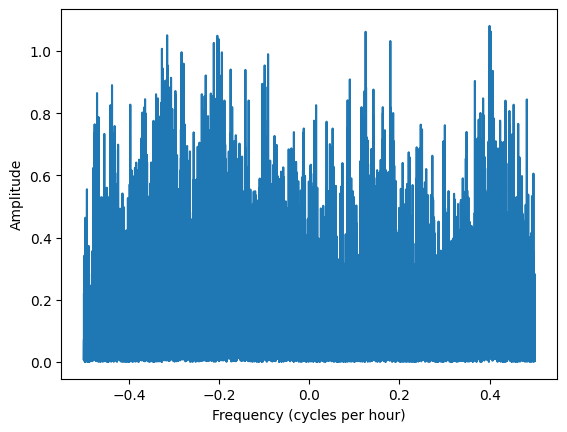

In [10]:
# Plotting the spectrum using Plotly
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=frequencies, y=fft_result.real, name='Real part'))
# fig.add_trace(go.Scatter(x=frequencies, y=fft_result.imag, name='Imaginary part'))
# fig.update_layout(title='Spectrum', xaxis_title='Frequency', yaxis_title='Amplitude')
# fig.show()

import matplotlib.pyplot as plt

# Plotting the spectrum
plt.plot(frequencies, np.abs(fft_result))
plt.xlabel('Frequency (cycles per hour)')
plt.ylabel('Amplitude')
plt.show()

In [11]:
# Identifying dominant frequency and converting to period
dominant_frequency = abs(frequencies[np.argmax(np.abs(fft_result))])
dominant_period = 1 / dominant_frequency  # Convert to hours per cycle

print(f'Dominant frequency: {dominant_frequency} cycles per hour')

Dominant frequency: 0.39980992206804794 cycles per hour


In [12]:
# # Let's decompose the series
# from statsmodels.tsa.seasonal import seasonal_decompose

# decomposition = seasonal_decompose(data[column_name], model='additive', period=24*7)

# # Lets plot the decomposition using plotly

# # Trend
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=data.index, y=decomposition.trend, name='Trend'))

# fig.update_layout(title='Trend', xaxis_title='Date', yaxis_title=column_name)
# fig.show()

# # Seasonality
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=data.index, y=decomposition.seasonal, name='Seasonality'))

# fig.update_layout(title='Seasonality', xaxis_title='Date', yaxis_title=column_name)
# fig.show()

# # Residual
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=data.index, y=decomposition.resid, name='Residual'))

# fig.update_layout(title='Residual', xaxis_title='Date', yaxis_title=column_name)
# fig.show()

# # fig = decomposition.plot()

In [13]:
# Lets decompose the series using Loess

stl = STL(data[column_name], period=24, robust=True)
res = stl.fit()

# Lets plot the decomposition using plotly

# Trend
fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=res.trend, name='Trend'))

fig.update_layout(title='Trend', xaxis_title='Date', yaxis_title=column_name)
fig.show()

# Seasonality
fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=res.seasonal, name='Seasonality'))

fig.update_layout(title='Seasonality', xaxis_title='Date', yaxis_title=column_name)
fig.show()

# Residual
fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=res.resid, name='Residual'))

fig.update_layout(title='Residual', xaxis_title='Date', yaxis_title=column_name)
fig.show()

# fig = res.plot()

In [14]:
# Add the trend, seasonality and residual to the original data
data['processed_log_return_wtmra_0_trend'] = res.trend
data['processed_log_return_wtmra_0_trend_seasonal'] = res.seasonal
data['processed_log_return_wtmra_0_trend_residual'] = res.resid

In [15]:
# remove the nan values
data = data.dropna()

In [16]:
data

,processed_log_return_wtmra_0,processed_log_return_wtmra_0_trend,processed_log_return_wtmra_0_trend_seasonal,processed_log_return_wtmra_0_trend_residual
date,,,,
2018-12-31 00:00:00,0.168167,0.003675,0.141220,0.023272
2018-12-31 01:00:00,-0.097854,0.003602,-0.050027,-0.051429
2018-12-31 02:00:00,0.087226,0.003528,-0.038696,0.122394
2018-12-31 03:00:00,-0.363237,0.003451,-0.230271,-0.136418
2018-12-31 04:00:00,0.354260,0.003372,0.236634,0.114254
...,...,...,...,...
2021-12-30 20:00:00,-0.021361,0.023493,-0.103509,0.058655
2021-12-30 21:00:00,-0.175831,0.023428,-0.023426,-0.175833
2021-12-30 22:00:00,0.283100,0.023364,-0.011926,0.271662


In [17]:
# Exporting data
data.to_csv(f'../data/02d-output-{data_name}-log-return-temporal_decomposition.csv')